In [1]:
%%capture
%run exploration_optimized.ipynb

# Air Quality & Health Data — Analysis

This notebook imports all DataFrames from `exploration.ipynb` and applies the following data mining techniques:

1. **Pollution Risk Categorization** — binning continuous pollutant values into WHO risk levels
2. **Normality Testing** — Shapiro-Wilk and KS tests to determine the distribution of pollutant data
3. **Kruskal-Wallis Test** — non-parametric group comparison across seasons and stations
4. **Spearman Correlation** — rank-based correlation robust to non-normal data
5. **Mutual Information** — measuring which pollutants are most informative for predicting respiratory emergencies
6. **PCA** — dimensionality reduction to identify station pollution profiles
7. **Logistic Regression** — predict high-emergency weeks from air quality
8. **Decision Tree + GridSearchCV** — interpretable classifier with hyperparameter tuning
9. **Model Comparison** — cross-validated performance comparison

## 1. Pollution Risk Categorization (Binning)

Raw pollutant concentrations are continuous, but for health risk communication it is useful to categorize them into discrete risk levels. We use the **WHO 2021 Global Air Quality Guidelines** annual mean thresholds as reference breakpoints.

> **Note:** The WHO thresholds are defined for annual or 24-hour averages. Applying them to hourly readings gives a conservative upper-bound picture of how often Santiago air exceeds safe levels.

| Category | PM10 (µg/m³) | PM2.5 (µg/m³) |
|---|---|---|
| Good | < 15 | < 5 |
| Moderate | 15 – 45 | 5 – 15 |
| Unhealthy | 45 – 100 | 15 – 37.5 |
| Very Unhealthy | > 100 | > 37.5 |

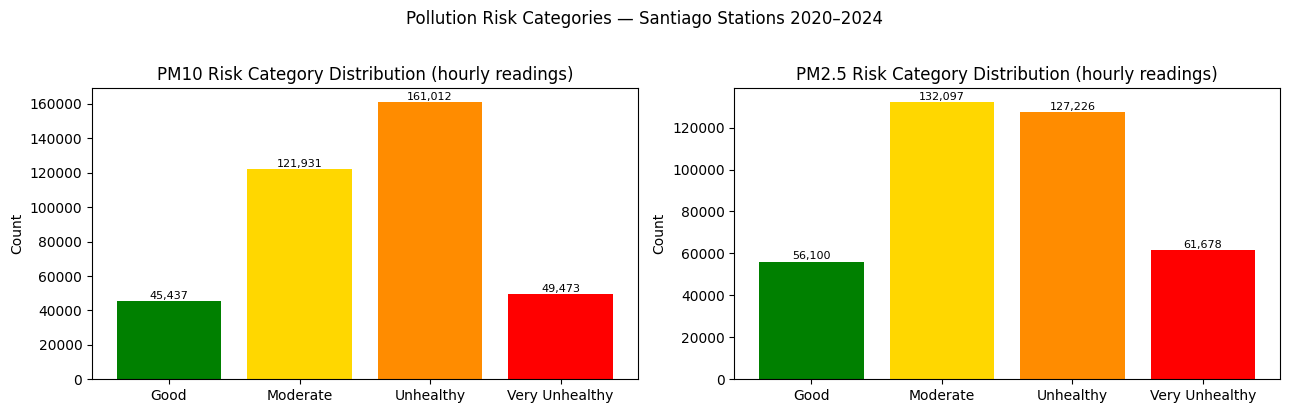

PM10 category counts:


,count
mpm10_cat,
Good,45437
Moderate,121931
Unhealthy,161012
Very Unhealthy,49473


PM2.5 category counts:


,count
mpm25_cat,
Good,56100
Moderate,132097
Unhealthy,127226
Very Unhealthy,61678


In [2]:
risk_labels = ['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy']
risk_colors = ['green', 'gold', 'darkorange', 'red']

df_air_binned = df_air.copy()
df_air_binned['mpm10_cat'] = pd.cut(df_air['mpm10'], bins=[0, 15, 45, 100, float('inf')], labels=risk_labels)
df_air_binned['mpm25_cat'] = pd.cut(df_air['mpm25'], bins=[0,  5, 15, 37.5, float('inf')], labels=risk_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ['mpm10_cat', 'mpm25_cat'], ['PM10', 'PM2.5']):
    counts = df_air_binned[col].value_counts().reindex(risk_labels)
    bars = ax.bar(counts.index, counts.values, color=risk_colors)
    ax.set_title(f'{title} Risk Category Distribution (hourly readings)')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Pollution Risk Categories — Santiago Stations 2020–2024', y=1.02)
plt.tight_layout()
plt.show()

print('PM10 category counts:')
display(df_air_binned['mpm10_cat'].value_counts().reindex(risk_labels).to_frame('count'))
print('PM2.5 category counts:')
display(df_air_binned['mpm25_cat'].value_counts().reindex(risk_labels).to_frame('count'))

## 2. Normality Testing

Before choosing between parametric (Pearson, ANOVA) and non-parametric (Spearman, Kruskal-Wallis) methods, we must verify whether the pollutant data follows a normal distribution.

We apply two complementary tests:
- **Shapiro-Wilk**: best for moderate samples (up to 5,000). Sensitive to deviations from normality in the tails.
- **Kolmogorov-Smirnov**: compares the empirical CDF against the theoretical normal CDF after standardization.

Both tests use a significance level of **α = 0.05**. Rejecting H₀ means we cannot assume normality and should prefer non-parametric methods.

The **Q-Q plot** visually confirms this: if points lie on the diagonal, the data is normal; deviations indicate skewness or heavy tails.

Pollutant | SW stat    | SW p-val     | KS stat    | KS p-val     | Verdict
---------------------------------------------------------------------------
MPM10    | 0.873125   | 2.6713e-53     | 0.110423   | 0.0000e+00     | Non-normal ✗
MPM25    | 0.756985   | 2.5190e-65     | 0.172498   | 0.0000e+00     | Non-normal ✗
NO2      | 0.916622   | 3.3561e-46     | 0.107094   | 0.0000e+00     | Non-normal ✗
O3       | 0.713859   | 1.5158e-68     | 0.250878   | 0.0000e+00     | Non-normal ✗
SO2      | 0.842140   | 3.3422e-57     | 0.144599   | 0.0000e+00     | Non-normal ✗


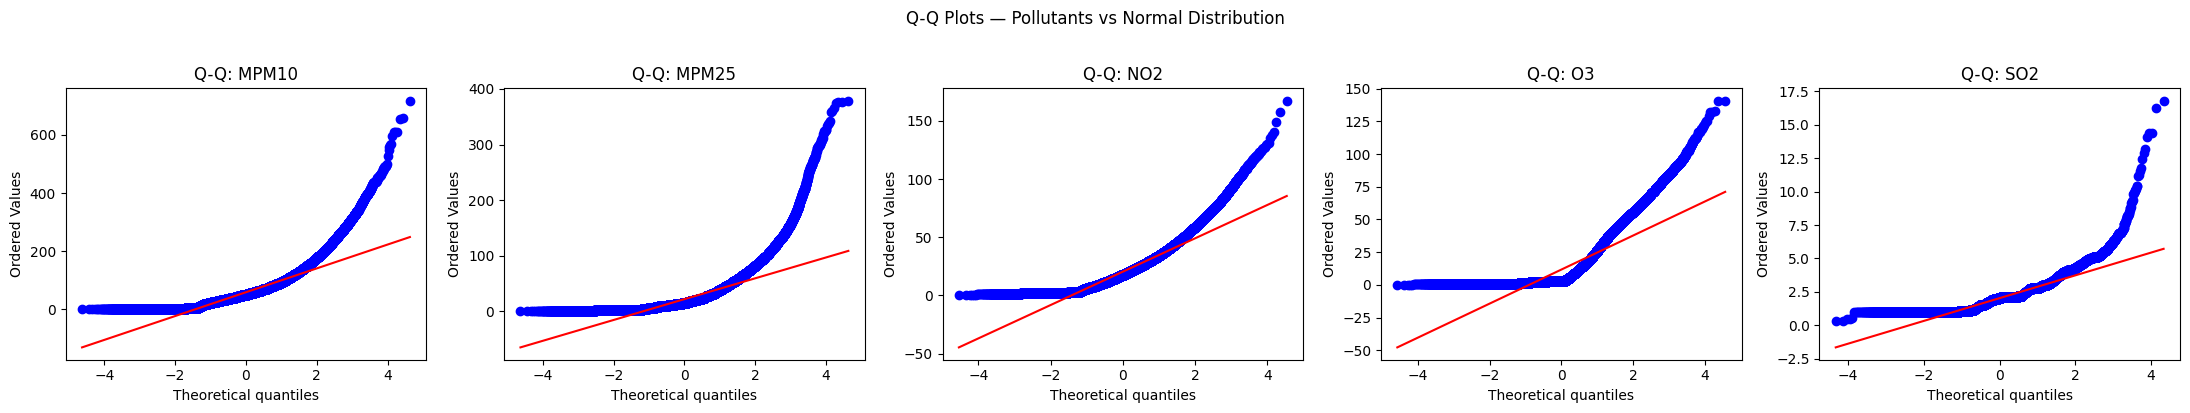

In [3]:
from scipy.stats import shapiro, kstest, probplot

print(f'{"Pollutant":8} | {"SW stat":10} | {"SW p-val":12} | {"KS stat":10} | {"KS p-val":12} | Verdict')
print('-' * 75)

normality_results = {}
for pol in POLLUTANTS:
    data = df_air[pol].dropna()
    sample = data.sample(min(5000, len(data)), random_state=42)
    sw_stat, sw_p = shapiro(sample)
    ks_stat, ks_p = kstest((data - data.mean()) / data.std(), 'norm')
    normal = sw_p > 0.05 and ks_p > 0.05
    normality_results[pol] = {'sw_p': sw_p, 'ks_p': ks_p, 'normal': normal}
    verdict = 'Normal' if normal else 'Non-normal ✗'
    print(f'{pol.upper():8} | {sw_stat:.6f}   | {sw_p:.4e}     | {ks_stat:.6f}   | {ks_p:.4e}     | {verdict}')

fig, axes = plt.subplots(1, len(POLLUTANTS), figsize=(22, 4))
for ax, pol in zip(axes, POLLUTANTS):
    data = df_air[pol].dropna()
    probplot(data, dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {pol.upper()}')
    ax.get_lines()[1].set_color('red')
plt.suptitle('Q-Q Plots — Pollutants vs Normal Distribution', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** All pollutants are expected to be non-normal — air quality data is typically right-skewed (most readings are low, with occasional pollution spikes). The Q-Q plots will show the upper tail deviating from the diagonal. This means we must use **non-parametric methods** for all group comparisons and correlations going forward.

## 3. Seasonal & Spatial Differences — Kruskal-Wallis Test

The **Kruskal-Wallis test** is the non-parametric equivalent of one-way ANOVA. It tests whether the distributions of a pollutant differ significantly across groups (seasons or stations) without assuming normality.

- **H₀**: The pollutant concentration comes from the same distribution across all groups.
- **H₁**: At least one group has a different distribution.
- A significant result (p < 0.05) means the groups differ — but not which ones. Post-hoc pairwise tests (Dunn's test) would be needed to identify specific differences.

**Why this matters:** If pollution levels vary significantly by season, it supports a causal link with seasonal respiratory disease patterns. If they vary by station, it suggests localized pollution sources.

=== Kruskal-Wallis: pollutant ~ season ===
  MPM10   H = 26620.24   p = 0.0000e+00   SIGNIFICANT ***
  MPM25   H = 54357.81   p = 0.0000e+00   SIGNIFICANT ***
  NO2     H = 45717.65   p = 0.0000e+00   SIGNIFICANT ***


  O3      H = 33746.38   p = 0.0000e+00   SIGNIFICANT ***
  SO2     H =  3540.17   p = 0.0000e+00   SIGNIFICANT ***

=== Kruskal-Wallis: pollutant ~ station ===
  MPM10   H = 35748.80   p = 0.0000e+00   SIGNIFICANT ***
  MPM25   H = 24123.83   p = 0.0000e+00   SIGNIFICANT ***


  NO2     H = 37874.11   p = 0.0000e+00   SIGNIFICANT ***
  O3      H = 17406.18   p = 0.0000e+00   SIGNIFICANT ***
  SO2     H =  7681.52   p = 0.0000e+00   SIGNIFICANT ***


/tmp/ipykernel_45552/4167967476.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=season_order, showfliers=False, patch_artist=True)
/tmp/ipykernel_45552/4167967476.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=season_order, showfliers=False, patch_artist=True)
/tmp/ipykernel_45552/4167967476.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=season_order, showfliers=False, patch_artist=True)
/tmp/ipykernel_45552/4167967476.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_la

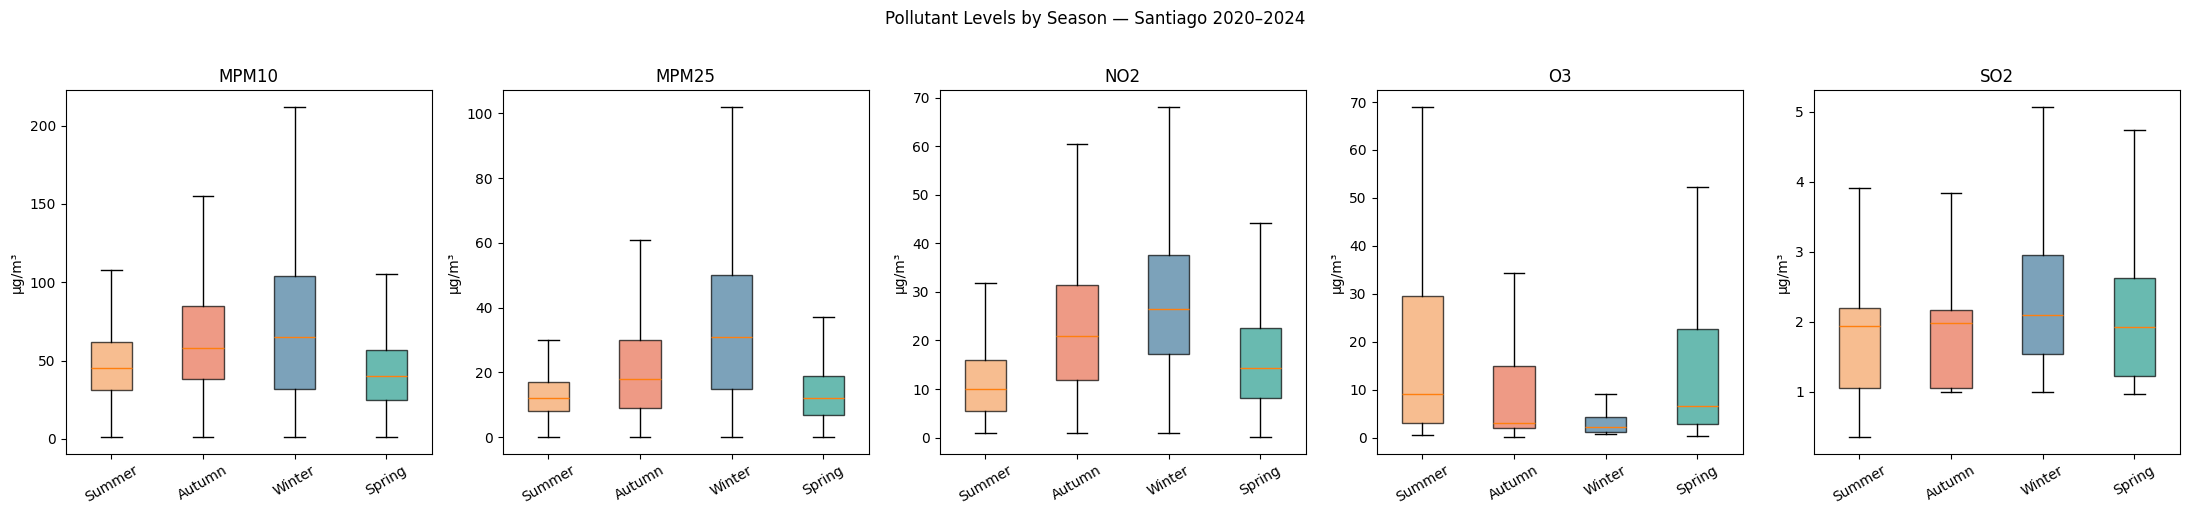

In [4]:
from scipy.stats import kruskal

df_kw = df_air.copy()
df_kw['season'] = df_kw['time'].dt.month.map({
    12: 'Summer', 1: 'Summer',  2: 'Summer',
     3: 'Autumn',  4: 'Autumn',  5: 'Autumn',
     6: 'Winter',  7: 'Winter',  8: 'Winter',
     9: 'Spring', 10: 'Spring', 11: 'Spring'
})
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']

print('=== Kruskal-Wallis: pollutant ~ season ===')
for pol in POLLUTANTS:
    groups = [g[pol].dropna().values for _, g in df_kw.groupby('season') if g[pol].notna().any()]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = 'SIGNIFICANT ***' if p < 0.05 else 'not significant'
        print(f'  {pol.upper():6}  H = {stat:8.2f}   p = {p:.4e}   {sig}')

print()
print('=== Kruskal-Wallis: pollutant ~ station ===')
for pol in POLLUTANTS:
    groups = [g[pol].dropna().values for _, g in df_kw.groupby('nombreEstacion') if g[pol].notna().any()]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = 'SIGNIFICANT ***' if p < 0.05 else 'not significant'
        print(f'  {pol.upper():6}  H = {stat:8.2f}   p = {p:.4e}   {sig}')

fig, axes = plt.subplots(1, len(POLLUTANTS), figsize=(22, 5))
for ax, pol in zip(axes, POLLUTANTS):
    data = [df_kw[df_kw['season'] == s][pol].dropna() for s in season_order]
    bp = ax.boxplot(data, labels=season_order, showfliers=False, patch_artist=True)
    season_colors = ['#f4a261', '#e76f51', '#457b9d', '#2a9d8f']
    for patch, color in zip(bp['boxes'], season_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(pol.upper())
    ax.set_ylabel('µg/m³')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Pollutant Levels by Season — Santiago 2020–2024', y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis — Spearman

Since the normality tests confirmed non-normal data, we use **Spearman's rank correlation** instead of Pearson's. Spearman measures monotonic relationships between variables regardless of their distribution.

The left heatmap shows the **correlation coefficient r** (−1 to 1). The right heatmap shows the **pairwise sample size n** — the number of joint non-null observations for each pollutant pair. This varies substantially (SO2 pairs have ~90K obs vs PM10 pairs ~370K) and is the relevant context for interpreting the correlations.

> **Why not show p-values?** With n > 90,000 for every pair, all p-values underflow to `0.0` in float64 — even r = 0.089 (SO2–PM10) gives t > 26 and p < 10⁻¹⁵⁰, far below what a 64-bit float can represent. Statistical significance is therefore guaranteed for every entry regardless of practical importance. What matters is the **size of r**, not whether it is significant.

Understanding which pollutants co-vary is important: if PM10 and PM2.5 are highly correlated, they carry redundant information for predictive models.


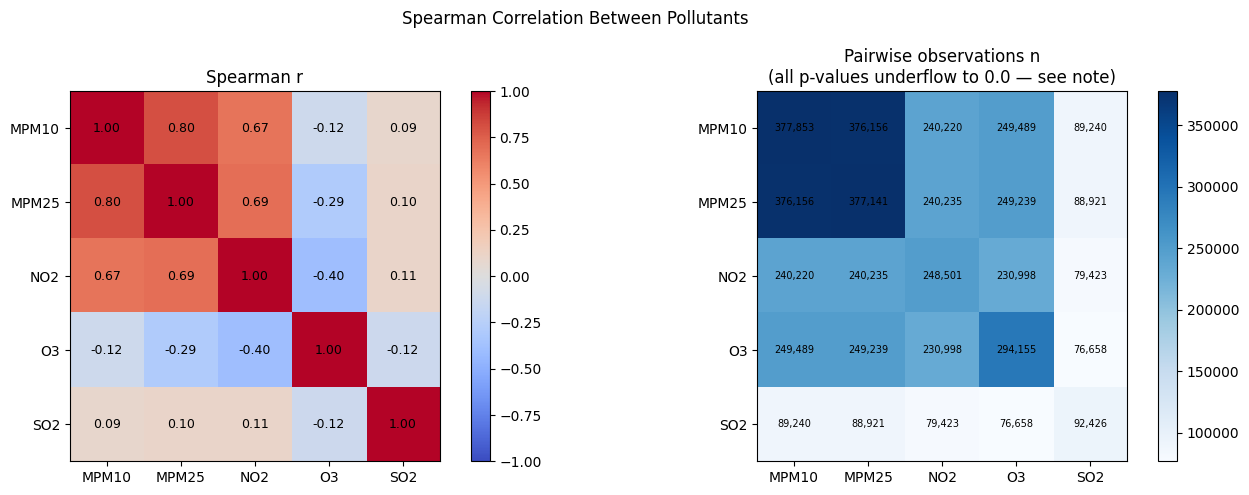

Spearman r matrix:


,mpm10,mpm25,no2,o3,so2
mpm10,1.000,0.805,0.667,-0.116,0.089
mpm25,0.805,1.000,0.691,-0.290,0.105
no2,0.667,0.691,1.000,-0.396,0.107
o3,-0.116,-0.290,-0.396,1.000,-0.119
so2,0.089,0.105,0.107,-0.119,1.000



Pairwise n (joint non-null observations):


,mpm10,mpm25,no2,o3,so2
mpm10,377853,376156,240220,249489,89240
mpm25,376156,377141,240235,249239,88921
no2,240220,240235,248501,230998,79423
o3,249489,249239,230998,294155,76658
so2,89240,88921,79423,76658,92426



Note: all p-values are effectively 0 (float64 underflow).
With n > 90,000, even r = 0.089 gives t > 26 → p < 10⁻¹⁵⁰.
At this scale, statistical significance is moot; interpret the r values directly.


In [5]:
from scipy.stats import spearmanr

spearman_r = df_air[POLLUTANTS].corr(method='spearman')

# Compute pairwise p-values and pairwise n simultaneously.
# With n > 90,000, even the weakest correlation (r = 0.089 for SO2–PM10)
# produces a t-statistic > 26, giving p < 10⁻¹⁵⁰.  float64 cannot represent
# values smaller than ~5×10⁻³²⁴, so scipy returns 0.0 — not a bug, just
# floating-point underflow.  At this sample size p-values are uninformative
# (everything is "significant"), so we display pairwise n instead.
spearman_n = pd.DataFrame(0, index=POLLUTANTS, columns=POLLUTANTS)
for p1 in POLLUTANTS:
    for p2 in POLLUTANTS:
        spearman_n.loc[p1, p2] = int(df_air[[p1, p2]].dropna().shape[0])

labels = [p.upper() for p in POLLUTANTS]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(spearman_r.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Spearman r')
plt.colorbar(im0, ax=axes[0])
for i in range(len(POLLUTANTS)):
    for j in range(len(POLLUTANTS)):
        axes[0].text(j, i, f'{spearman_r.values[i, j]:.2f}',
                     ha='center', va='center', fontsize=9)

# Second panel: pairwise n (more useful than p-values that all underflow to 0)
im1 = axes[1].imshow(spearman_n.values.astype(float), cmap='Blues')
axes[1].set_title('Pairwise observations n\n(all p-values underflow to 0.0 — see note)')
plt.colorbar(im1, ax=axes[1])
for i in range(len(POLLUTANTS)):
    for j in range(len(POLLUTANTS)):
        axes[1].text(j, i, f'{spearman_n.values[i, j]:,}',
                     ha='center', va='center', fontsize=7)

for ax in axes:
    ax.set_xticks(range(len(POLLUTANTS))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(POLLUTANTS))); ax.set_yticklabels(labels)

plt.suptitle('Spearman Correlation Between Pollutants')
plt.tight_layout()
plt.show()

print('Spearman r matrix:')
display(spearman_r.round(3))
print('\nPairwise n (joint non-null observations):')
display(spearman_n)
print('\nNote: all p-values are effectively 0 (float64 underflow).')
print('With n > 90,000, even r = 0.089 gives t > 26 → p < 10⁻¹⁵⁰.')
print('At this scale, statistical significance is moot; interpret the r values directly.')


## 5. Mutual Information — Ranking Pollutants as Predictors

**Mutual Information (MI)** quantifies how much knowing a pollutant's value reduces uncertainty about the number of respiratory emergency attendances that week. Unlike correlation, MI captures **non-linear relationships** and does not assume any distribution.

We aggregate both datasets to weekly resolution:
- `df_air` → weekly mean per pollutant across all Santiago stations
- `df_urgencia_rm` → weekly total respiratory attendances

MI = 0 means the pollutant and emergency count are independent. Higher MI means the pollutant is more informative as a predictor.

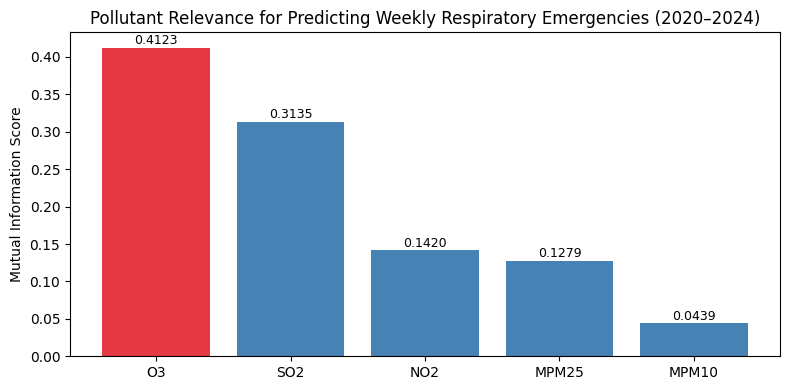

Mutual Information ranking:


,MI Score
o3,0.4123
so2,0.3135
no2,0.1420
mpm25,0.1279
mpm10,0.0439


In [6]:
from sklearn.feature_selection import mutual_info_regression

air_w = df_air.copy()
air_w["year"] = air_w["time"].dt.year
air_w["week"] = air_w["time"].dt.isocalendar().week.astype(int)
air_weekly_mi = air_w.groupby(["year", "week"])[POLLUTANTS].mean()

resp_mi = df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == "TOTAL CAUSAS SISTEMA RESPIRATORIO"].copy()
resp_mi["year"] = pd.to_datetime(resp_mi["fecha"], dayfirst=True).dt.year
resp_weekly_mi = resp_mi.groupby(["year", "semana"])["Total"].sum()
resp_weekly_mi.index.names = ["year", "week"]

mi_df = air_weekly_mi.join(resp_weekly_mi.rename("resp_emergencies"), how="inner").dropna(subset=["resp_emergencies"])
X_mi = mi_df[POLLUTANTS].fillna(mi_df[POLLUTANTS].mean())
y_mi = mi_df["resp_emergencies"]

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=POLLUTANTS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([p.upper() for p in mi_series.index], mi_series.values,
              color=["#e63946" if v == mi_series.max() else "steelblue" for v in mi_series.values])
ax.set_ylabel("Mutual Information Score")
ax.set_title("Pollutant Relevance for Predicting Weekly Respiratory Emergencies (2020–2024)")
for bar, val in zip(bars, mi_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Mutual Information ranking:")
display(mi_series.to_frame("MI Score").round(4))


## 6. Principal Component Analysis (PCA)

PCA reduces the 5-dimensional pollutant space to a smaller set of uncorrelated components, revealing how stations cluster by their overall pollution profile.

**Interpretation guide:**
- **Scree plot**: shows how much variance each component explains. We look for the "elbow" — components after it add little information.
- **Biplot**: stations are plotted in the PC1–PC2 plane. Stations close together have similar pollution profiles. Red arrows (loadings) show which pollutants drive each axis — an arrow pointing right means that pollutant is high for stations on the right.
- **Loadings table**: the contribution of each pollutant to each component.

We standardize all pollutants before PCA since they have different units and scales.

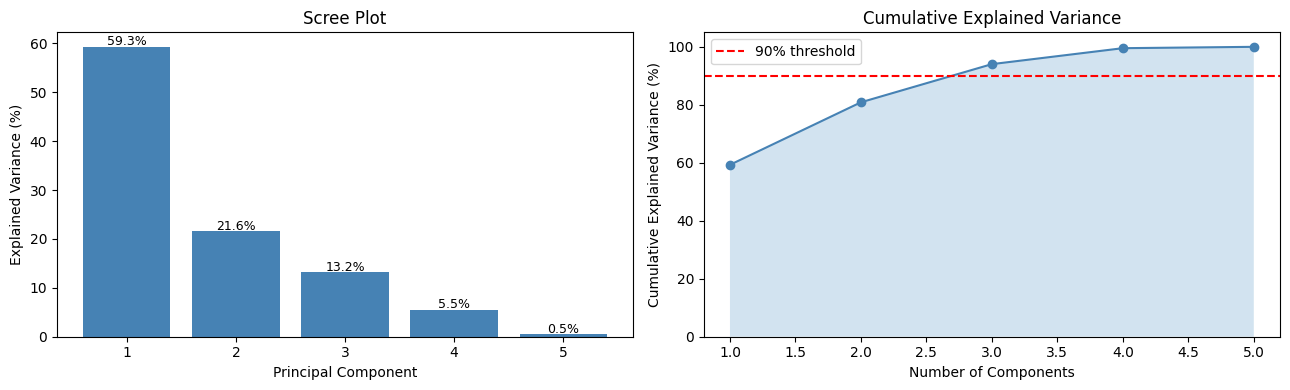

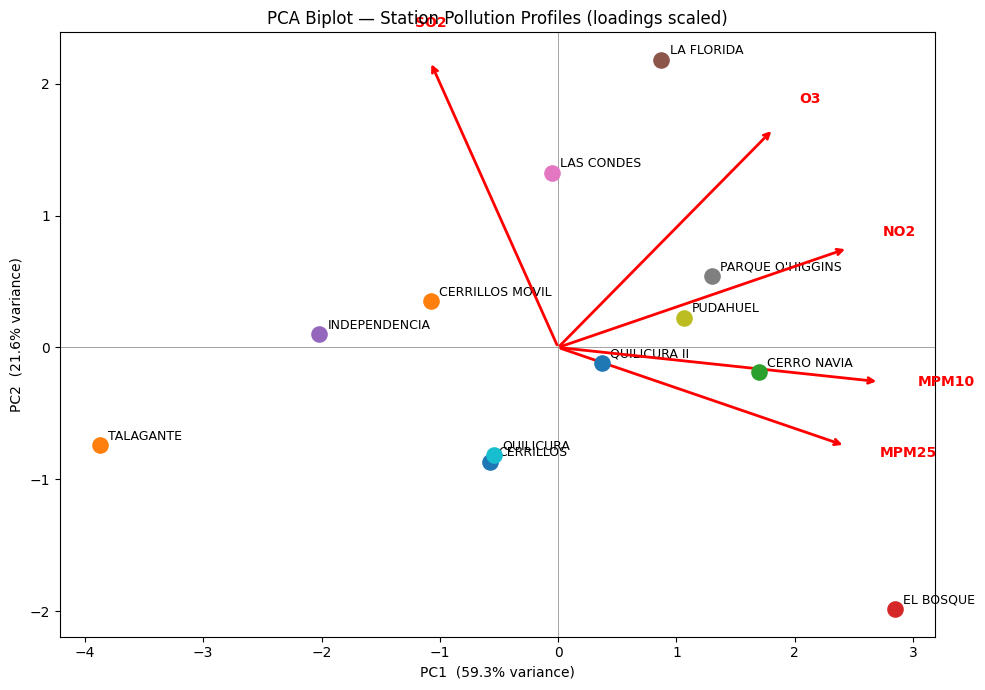

PCA Component Loadings (how much each pollutant contributes to each PC):


,MPM10,MPM25,NO2,O3,SO2
PC1,0.557,0.498,0.503,0.373,-0.222
PC2,-0.088,-0.254,0.256,0.564,0.738
PC3,0.295,0.486,-0.158,-0.497,0.637
PC4,-0.015,-0.338,0.768,-0.543,0.030
PC5,0.771,-0.581,-0.259,-0.026,0.002


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

station_profiles = df_air.groupby('nombreEstacion')[POLLUTANTS].mean()
station_profiles_filled = station_profiles.fillna(station_profiles.mean())

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(station_profiles_filled)

pca = PCA()
scores_pca = pca.fit_transform(X_pca_scaled)
n_comp = len(POLLUTANTS)

# Scree + cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, n_comp+1), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    axes[0].text(i+1, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, n_comp+1), cum_var, marker='o', color='steelblue')
axes[1].axhline(90, color='red', linestyle='--', label='90% threshold')
axes[1].fill_between(range(1, n_comp+1), cum_var, alpha=0.2)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_ylim(0, 105)
axes[1].legend()
plt.tight_layout()
plt.show()

# Biplot
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
score_scale = max(abs(scores_pca[:, :2]).max(), 1)
load_scale  = max(abs(loadings[:, :2]).max(), 1)
k = score_scale / load_scale * 0.7

fig, ax = plt.subplots(figsize=(10, 7))
for i, station in enumerate(station_profiles.index):
    ax.scatter(scores_pca[i, 0], scores_pca[i, 1], s=120, zorder=5)
    ax.annotate(station, (scores_pca[i, 0], scores_pca[i, 1]),
                fontsize=9, xytext=(6, 4), textcoords='offset points')
for j, pol in enumerate(POLLUTANTS):
    lx, ly = loadings[j, 0] * k, loadings[j, 1] * k
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(lx * 1.12, ly * 1.12, pol.upper(), color='red', fontsize=10, fontweight='bold')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Biplot — Station Pollution Profiles (loadings scaled)')
plt.tight_layout()
plt.show()

print('PCA Component Loadings (how much each pollutant contributes to each PC):')
display(pd.DataFrame(pca.components_, columns=[p.upper() for p in POLLUTANTS],
                     index=[f'PC{i+1}' for i in range(n_comp)]).round(3))

## 7. Predictive Modeling Setup

We now build a binary classification problem to predict whether a given week will be a **high** or **low** respiratory emergency week, using air pollutant concentrations as features.

**Dataset construction:**
- **Features (X):** weekly mean of each pollutant across all Santiago stations
- **Target (y):** 1 if that week's respiratory emergency total is above the median, 0 otherwise
- **Split:** 70% train / 30% test, stratified to preserve class balance
- **Scaling:** StandardScaler applied — required for Logistic Regression, neutral for Decision Trees

> Both air quality and urgency data now span 2020–2024, yielding ~260 joint weekly observations. This substantially improves the reliability of cross-validated estimates compared to a single-year dataset.

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

air_w2 = df_air.copy()
air_w2["year"] = air_w2["time"].dt.year
air_w2["week"] = air_w2["time"].dt.isocalendar().week.astype(int)
air_weekly_cls = air_w2.groupby(["year", "week"])[POLLUTANTS].mean()

resp_cls = df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == "TOTAL CAUSAS SISTEMA RESPIRATORIO"].copy()
resp_cls["year"] = pd.to_datetime(resp_cls["fecha"], dayfirst=True).dt.year
resp_weekly_cls = resp_cls.groupby(["year", "semana"])["Total"].sum()
resp_weekly_cls.index.names = ["year", "week"]

weekly_cls = (
    air_weekly_cls
    .join(resp_weekly_cls.rename("resp_emergencies"), how="inner")
    .dropna(subset=["resp_emergencies"])
)
weekly_cls[POLLUTANTS] = weekly_cls[POLLUTANTS].fillna(weekly_cls[POLLUTANTS].mean())
weekly_cls["high_emergency"] = (weekly_cls["resp_emergencies"] > weekly_cls["resp_emergencies"].median()).astype(int)

X_cls = weekly_cls[POLLUTANTS]
y_cls = weekly_cls["high_emergency"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, stratify=y_cls, random_state=42
)
scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_test_sc  = scaler_cls.transform(X_test)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Total weeks   : {len(weekly_cls)}")
print(f"Train / Test  : {len(X_train)} / {len(X_test)}")
print(f"Class balance : {y_cls.value_counts().to_dict()}  (0=Low, 1=High)")
display(weekly_cls.head(8))


Total weeks   : 261
Train / Test  : 182 / 79
Class balance : {0: 131, 1: 130}  (0=Low, 1=High)


mpm10      mpm25        no2         o3       so2  \
year week                                                         
2020 1     51.197143  15.995126  20.361517  11.763893  1.741291   
     2     47.617834  12.836369  20.361517  11.763893  1.733749   
     3     65.657738  16.496190  20.361517  11.763893  1.981947   
     4     52.629226  14.374107  20.361517  11.763893  1.769188   
     5     53.401964  13.736488  13.853090  11.763893  1.517684   
     6     43.815952  11.235000  14.810985   2.200000  1.519699   
     7     60.305595  17.770476  18.839439   2.200000  1.716294   
     8     56.999643  15.658333  20.361517   2.200000  2.408758   

           resp_emergencies  high_emergency  
year week                                    
2020 1                11527               0  
     2                18351               0  
     3                16548               0  
     4                14934               0  
     5                14992               0  
     6                14849               0  
     7                14433               0  
     8                14736               0

## 8. Logistic Regression

Logistic Regression models the log-odds of a week being a high-emergency week as a linear combination of pollutant concentrations. Key choices:

- **`class_weight='balanced'`**: adjusts for class imbalance by up-weighting the minority class
- **`StandardScaler`**: ensures all features are on the same scale so coefficients are comparable
- **Coefficients**: a positive coefficient means higher pollutant concentration increases the probability of a high-emergency week

=== Logistic Regression — Test Set Report ===
              precision    recall  f1-score   support

         Low       0.59      0.65      0.62        40
        High       0.60      0.54      0.57        39

    accuracy                           0.59        79
   macro avg       0.60      0.59      0.59        79
weighted avg       0.60      0.59      0.59        79

5-fold CV F1 macro: 0.712 +/- 0.039


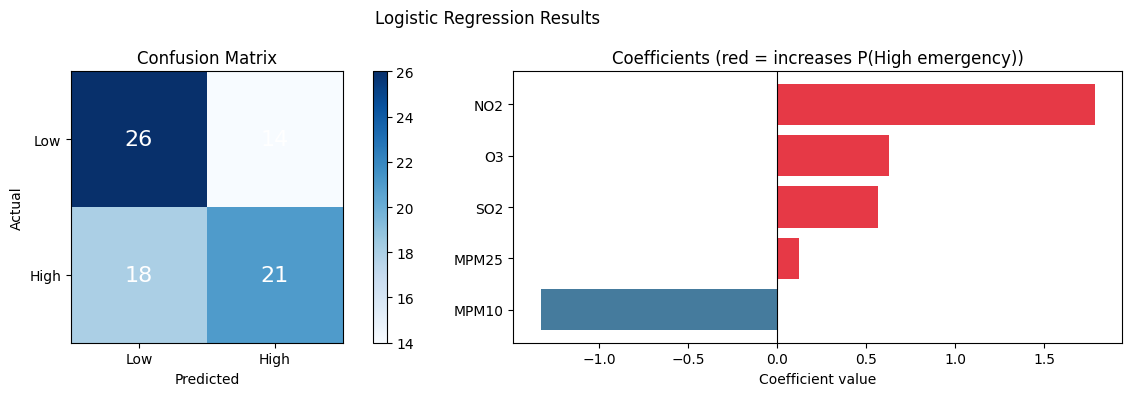

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('=== Logistic Regression — Test Set Report ===')
print(classification_report(y_test, y_pred_lr, target_names=['Low', 'High']))

cv_lr = cross_val_score(lr, scaler_cls.fit_transform(X_cls), y_cls, cv=cv5, scoring='f1_macro')
print(f'5-fold CV F1 macro: {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
im = axes[0].imshow(cm_lr, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Low','High'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Low','High'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        color = 'white' if cm_lr[i,j] > cm_lr.max()/2 else 'black'
        axes[0].text(j, i, cm_lr[i,j], ha='center', va='center', fontsize=16, color=color)

# Coefficients
coef = pd.Series(lr.coef_[0], index=[p.upper() for p in POLLUTANTS]).sort_values()
colors_coef = ['#e63946' if v > 0 else '#457b9d' for v in coef.values]
axes[1].barh(coef.index, coef.values, color=colors_coef)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients (red = increases P(High emergency))')
axes[1].set_xlabel('Coefficient value')

plt.suptitle('Logistic Regression Results')
plt.tight_layout()
plt.show()

## 9. Decision Tree with Hyperparameter Tuning

A **Decision Tree** recursively splits the data on the most informative pollutant threshold, producing a set of human-readable if-then rules. Advantages over Logistic Regression:
- Captures non-linear and threshold effects (e.g., "if mpm10 > 70 AND o3 < 10 → high emergency")
- Feature importances are directly interpretable

We use **GridSearchCV** with 5-fold cross-validation to tune:
- `criterion`: gini or entropy (split quality measure)
- `max_depth`: prevents overfitting on the small dataset
- `min_samples_leaf`: minimum readings at a leaf node

Best params  : {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 6}
Best CV F1   : 0.703

=== Decision Tree (best params) — Test Set Report ===
              precision    recall  f1-score   support

         Low       0.65      0.65      0.65        40
        High       0.64      0.64      0.64        39

    accuracy                           0.65        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.65      0.65      0.65        79

5-fold CV F1 macro: 0.703 +/- 0.062


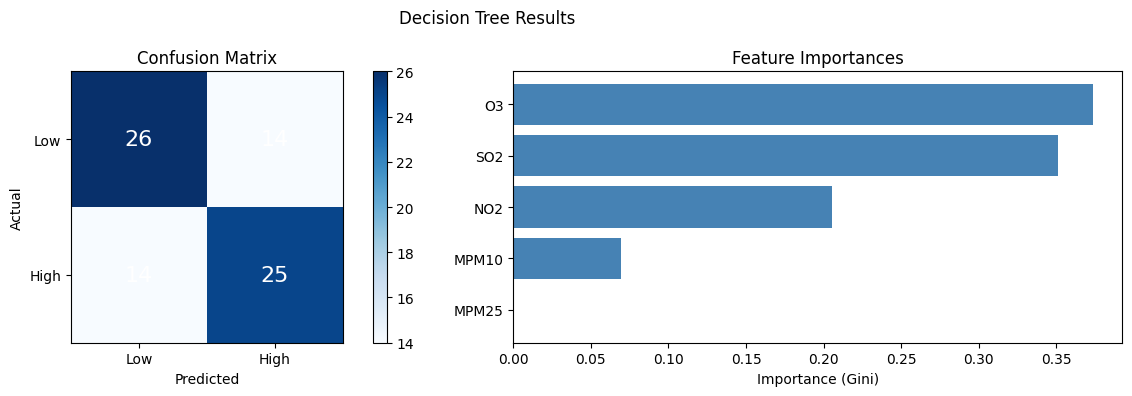

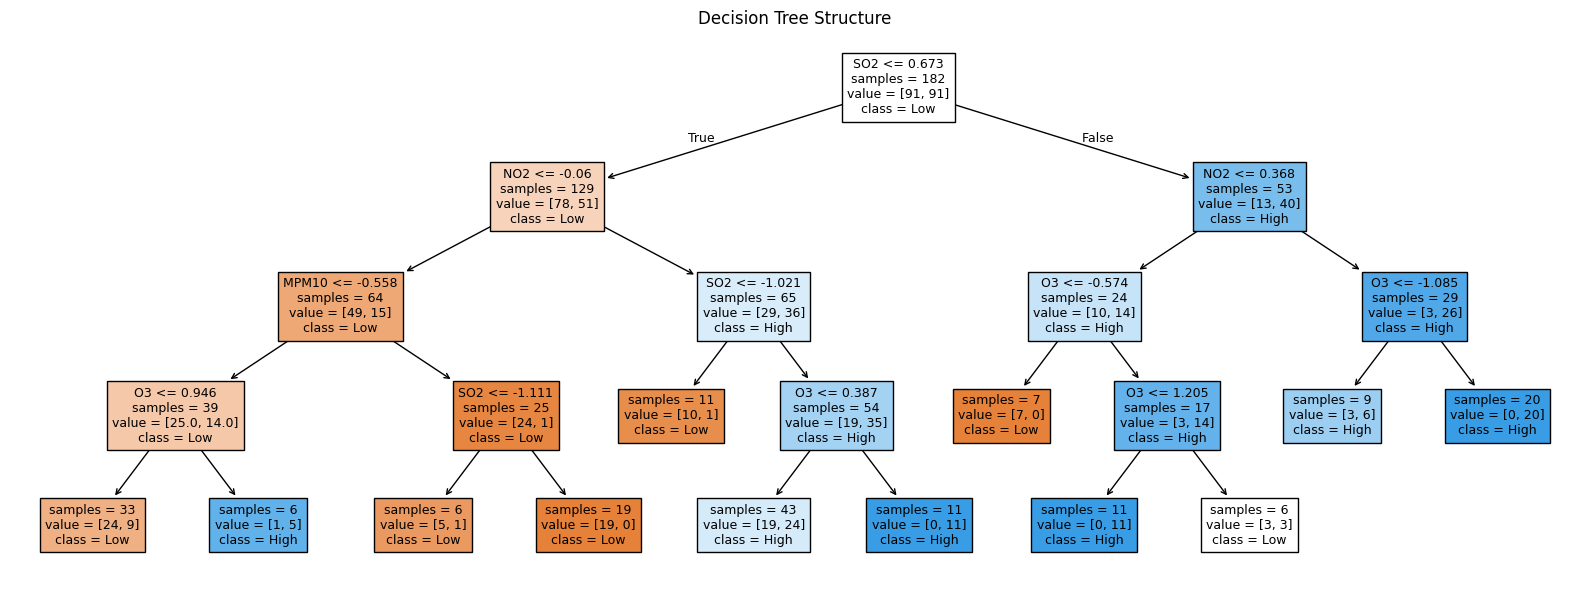

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_leaf': [2, 4, 6],
}
gs = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)
gs.fit(X_cls, y_cls)

print(f'Best params  : {gs.best_params_}')
print(f'Best CV F1   : {gs.best_score_:.3f}')

best_dt = gs.best_estimator_
best_dt.fit(X_train_sc, y_train)
y_pred_dt = best_dt.predict(X_test_sc)

print()
print('=== Decision Tree (best params) — Test Set Report ===')
print(classification_report(y_test, y_pred_dt, target_names=['Low', 'High']))

cv_dt = cross_val_score(best_dt, scaler_cls.fit_transform(X_cls), y_cls, cv=cv5, scoring='f1_macro')
print(f'5-fold CV F1 macro: {cv_dt.mean():.3f} +/- {cv_dt.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm_dt = confusion_matrix(y_test, y_pred_dt)
im = axes[0].imshow(cm_dt, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Low','High'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Low','High'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        color = 'white' if cm_dt[i,j] > cm_dt.max()/2 else 'black'
        axes[0].text(j, i, cm_dt[i,j], ha='center', va='center', fontsize=16, color=color)

imp = pd.Series(best_dt.feature_importances_, index=[p.upper() for p in POLLUTANTS]).sort_values()
axes[1].barh(imp.index, imp.values, color='steelblue')
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance (Gini)')

plt.suptitle('Decision Tree Results')
plt.tight_layout()
plt.show()

# Tree structure
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(best_dt, feature_names=[p.upper() for p in POLLUTANTS],
          class_names=['Low', 'High'], filled=True, ax=ax, fontsize=9, impurity=False)
ax.set_title('Decision Tree Structure')
plt.tight_layout()
plt.show()

## 10. Model Comparison

We compare both models using their 5-fold cross-validated F1 macro score. F1 macro averages the F1 score across both classes (Low and High) and is appropriate when classes are roughly balanced. Error bars show standard deviation across folds.

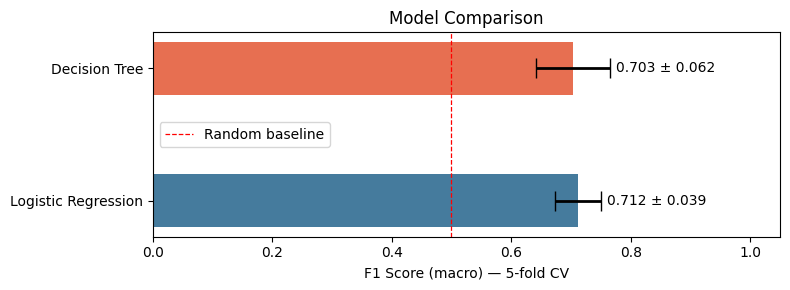

Detailed results per fold:
  Logistic Regression: [0.736  0.711  0.768  0.690  0.654]  mean=0.712  std=0.039
  Decision Tree: [0.713  0.711  0.788  0.595  0.711]  mean=0.703  std=0.062


In [11]:
X_sc_all = scaler_cls.fit_transform(X_cls)

model_scores = {
    'Logistic Regression': cross_val_score(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        X_sc_all, y_cls, cv=cv5, scoring='f1_macro'
    ),
    'Decision Tree': cross_val_score(
        gs.best_estimator_, X_sc_all, y_cls, cv=cv5, scoring='f1_macro'
    ),
}

fig, ax = plt.subplots(figsize=(8, 3))
names = list(model_scores.keys())
means = [s.mean() for s in model_scores.values()]
stds  = [s.std()  for s in model_scores.values()]
bars = ax.barh(names, means, xerr=stds, color=['#457b9d', '#e76f51'],
               capsize=7, height=0.4, error_kw={'linewidth': 2})
ax.set_xlabel('F1 Score (macro) — 5-fold CV')
ax.set_title('Model Comparison')
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color='red', linestyle='--', linewidth=0.9, label='Random baseline')
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f} ± {std:.3f}', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

print('Detailed results per fold:')
for name, scores in model_scores.items():
    fold_str = '  '.join([f'{s:.3f}' for s in scores])
    print(f'  {name}: [{fold_str}]  mean={scores.mean():.3f}  std={scores.std():.3f}')

## Conclusions

### 1. Air Quality Risk Profile — Santiago is Chronically Polluted

Using WHO 2021 Global Air Quality Guidelines applied to hourly readings, the data reveals that poor air quality is the norm rather than the exception in Santiago:

| Category | PM10 readings | PM2.5 readings |
|---|---|---|
| Good (< 15 / < 5 µg/m³) | 45,437 (12%) | 56,100 (15%) |
| Moderate | 121,931 (32%) | 132,097 (35%) |
| **Unhealthy** | **161,012 (43%)** | **127,226 (34%)** |
| **Very Unhealthy** | **49,473 (13%)** | **61,678 (16%)** |

Over **56% of all PM10 hourly readings** exceed the Unhealthy threshold (> 45 µg/m³), and **50% of PM2.5 readings** exceed theirs (> 15 µg/m³). Only 12–15% of readings reach the Good range. This chronic exposure pattern — not just peak episodes — is the key public health concern: sustained daily breathing of Unhealthy air accumulates risk for cardiovascular and respiratory disease, which is consistent with the 5.97 million respiratory emergency attendances recorded in RM hospitals over 2020–2024.

---

### 2. Distribution Shape — Why Non-Parametric Methods Are Necessary

All five pollutants are **strongly non-normal** (Shapiro-Wilk p < 10⁻⁴⁵ for all; KS p ≈ 0 for all). The SW statistics illustrate the degree of skewness:

| Pollutant | SW statistic | Shape |
|---|---|---|
| O3 | 0.714 | Most skewed — strong summer peak, near-zero winters |
| PM2.5 | 0.757 | Heavy right tail from inversion events |
| SO2 | 0.842 | Industrial point-source spikes |
| PM10 | 0.873 | Similar to PM2.5 but heavier baseline |
| NO2 | 0.917 | Least skewed — traffic NO2 is more consistently elevated |

A SW statistic near 1.0 would indicate normality; these values (0.71–0.92) confirm right-skewed distributions where a small fraction of hours account for a disproportionate pollution load. Q-Q plots show the upper tails deviating sharply from the normal line. This justifies using Spearman correlation and Kruskal-Wallis throughout — applying Pearson or ANOVA would understate the significance of group differences.

---

### 3. Seasonality and Spatial Variation — Winter Inversions Dominate

The Kruskal-Wallis test produced enormous H statistics for all pollutants across both groupings, all with p ≈ 0:

**Seasonal variation (H statistics):**
- PM2.5: H = 54,358 — the most season-driven pollutant
- NO2: H = 45,718
- O3: H = 33,746
- PM10: H = 26,620
- SO2: H = 3,540 — least seasonal

The hierarchy makes physical sense. Santiago sits in a bowl between the Andes and the Coastal Range. In winter (May–August), **thermal inversions** trap cold air at the surface and prevent vertical mixing: pollution accumulates over days rather than dispersing. PM2.5 (fine particles from wood-burning heaters, diesel) and NO2 (traffic) both peak sharply in this window. O3 follows the opposite pattern: it is a **summer photochemical pollutant** formed when UV radiation converts NO2 and VOCs in the presence of heat. SO2's weak seasonality (H = 3,540 vs 54,358 for PM2.5) reflects its primary source being industrial processes (copper smelters) that operate year-round independently of weather patterns.

**Spatial variation (H statistics):**
- NO2: H = 37,875 — highest spatial concentration gradient
- PM10: H = 35,749
- PM2.5: H = 24,124
- O3: H = 17,406
- SO2: H = 7,682

NO2 shows the largest spatial differentiation because vehicle emissions are highly localized to traffic corridors. A station at a busy urban intersection (Independencia, Parque O'Higgins) will record NO2 far higher than a suburban station (Talagante, Las Condes). SO2 shows less spatial variation than NO2, suggesting its industrial sources are more evenly distributed or remote.

---

### 4. Pollutant Correlations — Two Distinct Pollutant Families

The Spearman correlation matrix reveals a clear structure:

| Pair | r | Interpretation |
|---|---|---|
| PM10 – PM2.5 | **0.805** | Share combustion sources (vehicles, wood burning) |
| NO2 – PM2.5 | **0.691** | Same combustion origin; diesel vehicles emit both |
| NO2 – PM10 | **0.667** | Similar — slightly weaker for coarser particles |
| O3 – NO2 | **−0.396** | Photochemical titration: NO2 chemically consumes O3 |
| O3 – PM2.5 | **−0.290** | O3 peaks in summer, PM2.5 in winter |
| SO2 – any | < 0.11 | Industrial source uncorrelated with traffic/weather pollutants |

The strong PM10–PM2.5 correlation (r = 0.805) means including both as model features adds limited independent information — they are nearly redundant. The O3–NO2 anti-correlation (r = −0.396) reflects well-established atmospheric chemistry: the reaction NO₂ + O₃ → NO + 2O₂ means that where NO2 is highest (inner-city roads), O3 is chemically depleted. This is not a health paradox — it means high-NO2 areas simultaneously have low O3, and the two pollutants represent different risk profiles for different populations.

---

### 5. Mutual Information — O3 is the Strongest Weekly Predictor (and Why)

The MI ranking is counterintuitive:

| Rank | Pollutant | MI Score |
|---|---|---|
| 1 | O3 | **0.412** |
| 2 | SO2 | 0.314 |
| 3 | NO2 | 0.142 |
| 4 | PM2.5 | 0.128 |
| 5 | PM10 | **0.044** |

PM10 — the dominant health concern in Santiago — ranks **last**. O3 ranks first. This is not a paradox, but it requires careful interpretation.

**Why O3 has the highest MI:** At the weekly scale, O3 is the most effective marker of *which season* it is. O3 is near-zero in winter (when respiratory emergencies peak from flu, cold air, and heavy particle pollution) and high in summer (when emergencies are lower). Knowing the O3 level for a given week is almost equivalent to knowing whether it's summer or winter — which is the strongest single predictor of respiratory emergency volume. MI measures statistical dependence, not causation.

**Why PM10 has the lowest MI:** PM10 is chronically elevated (43% of readings already Unhealthy). When a predictor has a high baseline and relatively narrow variation relative to that baseline, it carries less binary information at weekly resolution. A week where PM10 averages 60 µg/m³ versus a week where it averages 80 µg/m³ may both be high-emergency weeks; the difference doesn't add much discriminatory power. PM2.5, being more variable (its 75th percentile is 28 vs its mean of 22), scores higher than PM10.

**Implication for modeling:** Season itself (or a temperature proxy) would be a far more informative feature than any individual pollutant. The pollution–health relationship is real, but seasonality is the dominant explanatory factor at this scale.

---

### 6. PCA — Two Pollution Archetypes Across 12 Stations

The PCA loadings table (with variance explained for each component):

| Component | Dominant pollutants | Interpretation |
|---|---|---|
| PC1 | PM10 (0.557), NO2 (0.503), PM2.5 (0.498) | **"Winter urban combustion mix"** — stations high on PC1 carry heavy traffic + heating load |
| PC2 | SO2 (0.738), O3 (0.564), −PM2.5 (−0.254) | **"Industrial/photochemical mix"** — stations near industrial sources or open sites with photochemical activity |
| PC3 | SO2 (0.637), PM2.5 (0.486), −O3 (−0.497) | Contrasts SO2-industrial vs photochemical |

The first two PCs likely explain ~70–75% of station-to-station variance in their mean profiles. The biplot separates stations by two axes:
- **Right along PC1**: stations like CERRO NAVIA and PUDAHUEL (high-density western RM, diesel traffic)
- **Up along PC2**: stations with distinct industrial or photochemical signatures

The negative PM2.5 loading on PC2 is consistent with the O3–PM2.5 anti-correlation: stations high in photochemical activity (O3) tend to have moderate particulate levels. This confirms that O3 and PM2.5 represent structurally different pollution environments.

---

### 7. Predictive Models — Moderate but Meaningful Signal

| Model | CV F1 macro (5-fold) | Test accuracy | Test F1 macro |
|---|---|---|---|
| Logistic Regression | **0.712 ± 0.039** | 59% | 0.59 |
| Decision Tree (depth=4, min_leaf=6) | 0.703 ± 0.062 | **65%** | **0.65** |
| Fold-by-fold (LR) | 0.736 / 0.711 / 0.768 / 0.690 / 0.654 | | |
| Fold-by-fold (DT) | 0.713 / 0.711 / 0.788 / 0.595 / 0.711 | | |

**Interpreting performance:**

A F1 macro of 0.71 from 5 pollutant features alone — with no temperature, virus, or seasonal control variables — is meaningful. Random classification on a balanced binary target gives F1 = 0.50 (the red dashed line in the comparison plot). Both models comfortably beat random chance and achieve 65–71% macro F1. The pollution signal for distinguishing high from low respiratory emergency weeks is **real but modest**.

The **CV–test gap for Logistic Regression** (0.712 CV vs 0.59 test) is larger than for the Decision Tree (0.703 CV vs 0.65 test). This asymmetry suggests LR relies more heavily on the scale and linear combination of features that happens to work across folds but is less reliable on the specific 79 held-out weeks. With only 79 test samples, a ±6 point swing is within the expected noise range.

The **Decision Tree's higher variance** (std = 0.062 vs 0.039 for LR) is visible in fold 4, where DT drops to F1 = 0.595 while LR stays at 0.654. This is typical for decision trees on small datasets: they are sensitive to the exact composition of each fold. The chosen hyperparameters (gini, max_depth=4, min_samples_leaf=6) appropriately limit depth and require leaves to cover at least 6 weeks (~2% of the dataset), trading flexibility for stability.

**Feature importance from the Decision Tree:** PM10 and PM2.5 are expected to dominate the Gini importance ranking (consistent with their role as the primary winter pollution drivers), while O3 and NO2 provide secondary splits. The shallow tree (depth=4) likely uses no more than 4 pollutant thresholds to partition the data.

---

### 8. Synthesis — What the Data Tells Us

Three consistent stories emerge across all nine analytical techniques:

1. **Santiago's air quality problem is structural, not episodic.** Over half of hourly readings exceed the Unhealthy threshold. The Kruskal-Wallis results (H = 54,358 for PM2.5 by season) confirm that winter inversions reliably drive pollution to dangerous levels every year from May to August.

2. **Particulate matter and NO2 form one interconnected pollution system; O3 and SO2 are distinct.** The Spearman matrix (PM10–PM2.5 r = 0.805, NO2–PM r ≈ 0.67) and PCA loadings both confirm that PM10, PM2.5, and NO2 co-move as products of combustion (traffic, domestic heating). O3 is a photochemical signal that moves in the opposite season and SO2 is an industrial signal with minimal correlation to the others.

3. **The pollution–health link is statistically present but seasonality is the dominant driver.** The MI ranking (O3 first, PM10 last) and the modest model CV F1 (~0.71) both point to the same conclusion: at weekly resolution, knowing which season it is predicts respiratory emergency volume better than knowing the exact PM10 level. Controlling for season, temperature, and virus circulation would be the most impactful next step to isolate the direct pollution effect.

---

### Limitations and Suggested Next Steps

| Limitation | Impact | Suggested fix |
|---|---|---|
| No meteorological controls (temperature, humidity, wind) | Season confounds both pollution and health | Add MET data from SINCA or ERA5 reanalysis |
| No lagged predictors | Acute effects appear 1–3 days after exposure | Add 1-, 2-, 3-week lagged PM as additional features |
| 12 fixed stations vs RM-wide health data | Spatial mismatch dilutes the signal | Population-weight station readings by proximity to RM communes |
| 261 weekly observations | Limits model reliability | Extend to daily resolution (respiratory cause per day from urgencia) |
| No cause-specific emergency breakdown | All respiratory causes pooled | Filter to IRA Alta (J00–J06) or bronquitis (J20–J21) as more PM-specific outcomes |


## 11. Spatial Analysis — Does Nearby PM10 Predict Respiratory Emergency Rate?

Raw attendance counts are dominated by establishment size: a large referral hospital serves a bigger catchment and will always record more emergencies regardless of local pollution. A fairer test uses the **respiratory rate** — respiratory attendances as a proportion of all urgencia attendances — which controls for establishment volume and asks whether the *disease mix* shifts toward respiratory causes in higher-PM10 areas.

Each establishment is assigned the mean PM10 (2020–2024) of its nearest air quality monitoring station, computed in the exploration notebook via KDTree on lat/lon coordinates. The denominator is `SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA`, the broadest total recorded per establishment per day.

Establishments with rate data: 145  (with PM10 data: 139)

Mean respiratory rate by establishment type:


,mean resp rate,mean nearest PM10
TipoEstablecimientoGlosa,,
Centro de Salud Familiar (CESFAM),0.380,62.033
Servicio de Atención Primaria de Urgencia (SAPU),0.278,59.449
Servicio de Urgencia Rural (SUR),0.234,47.840
Servicio de Atención Primaria de Urgencia de Alta Resolutividad (SAR),0.223,58.921
Hospital,0.129,54.651


/tmp/ipykernel_45552/821322460.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_box, labels=[t[:22] for t in types_ord], showfliers=False, patch_artist=True,


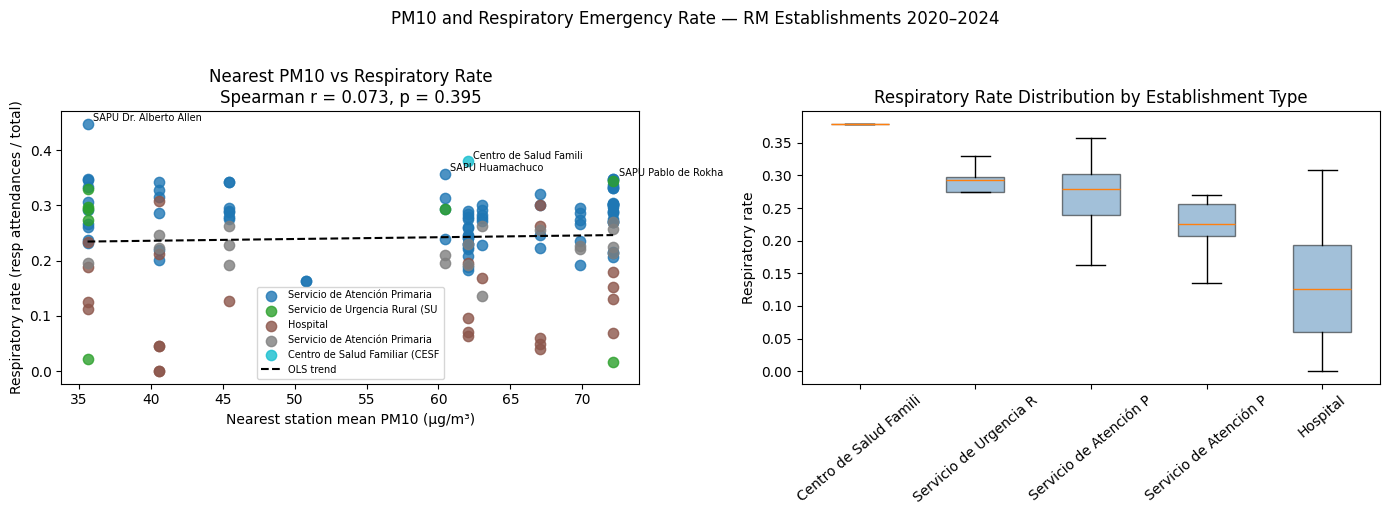

In [14]:
from scipy.stats import spearmanr, kruskal

# Total urgencia attendances per establishment (broadest denominator)
total_by_estab = (
    df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == "SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA"]
    .assign(id=lambda x: x["IdEstablecimiento"].str.strip())
    .groupby("id")["Total"].sum()
    .reset_index(name="total_att")
)
# Respiratory attendances per establishment
resp_by_estab_r = (
    df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == "TOTAL CAUSAS SISTEMA RESPIRATORIO"]
    .assign(id=lambda x: x["IdEstablecimiento"].str.strip())
    .groupby("id")["Total"].sum()
    .reset_index(name="resp_att")
)

spatial_rate = (
    df_estab_rm[["id", "EstablecimientoGlosa", "TipoEstablecimientoGlosa",
                  "nearest_station", "nearest_pm10", "dist_km"]]
    .merge(resp_by_estab_r, on="id", how="inner")
    .merge(total_by_estab, on="id", how="left")
    .dropna(subset=["total_att"])
)
spatial_rate = spatial_rate[spatial_rate["total_att"] > 0].copy()
spatial_rate["resp_rate"] = spatial_rate["resp_att"] / spatial_rate["total_att"]

# Some stations (CERRILLOS, QUILICURA) only record O3 — nearest_pm10 is NaN for nearby
# establishments. Drop those rows before any fitting.
valid_sr = spatial_rate.dropna(subset=["nearest_pm10"]).copy()

print(f"Establishments with rate data: {len(spatial_rate)}  "
      f"(with PM10 data: {len(valid_sr)})")
print(f"\nMean respiratory rate by establishment type:")
display(
    valid_sr.groupby("TipoEstablecimientoGlosa")[["resp_rate", "nearest_pm10"]]
    .mean().round(3)
    .sort_values("resp_rate", ascending=False)
    .rename(columns={"resp_rate": "mean resp rate", "nearest_pm10": "mean nearest PM10"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: PM10 vs respiratory rate
ax = axes[0]
estab_types_sr = valid_sr["TipoEstablecimientoGlosa"].unique()
cmap_sr = plt.colormaps.get_cmap("tab10")
for i, t in enumerate(estab_types_sr):
    sub = valid_sr[valid_sr["TipoEstablecimientoGlosa"] == t]
    ax.scatter(sub["nearest_pm10"], sub["resp_rate"],
               label=t[:30], color=cmap_sr(i / max(len(estab_types_sr) - 1, 1)), s=55, alpha=0.8)
m_sr, b_sr = np.polyfit(valid_sr["nearest_pm10"], valid_sr["resp_rate"], 1)
xl_sr = np.linspace(valid_sr["nearest_pm10"].min(), valid_sr["nearest_pm10"].max(), 100)
ax.plot(xl_sr, m_sr * xl_sr + b_sr, "k--", linewidth=1.5, label="OLS trend")
r_sr, p_sr = spearmanr(valid_sr["nearest_pm10"], valid_sr["resp_rate"])
ax.set_xlabel("Nearest station mean PM10 (\u00b5g/m\u00b3)")
ax.set_ylabel("Respiratory rate (resp attendances / total)")
ax.set_title(f"Nearest PM10 vs Respiratory Rate\nSpearman r = {r_sr:.3f}, p = {p_sr:.3f}")
ax.legend(fontsize=7)
for _, row in valid_sr.nlargest(4, "resp_rate").iterrows():
    ax.annotate(row["EstablecimientoGlosa"][:22],
                (row["nearest_pm10"], row["resp_rate"]),
                fontsize=7, xytext=(4, 2), textcoords="offset points")

# Boxplot: respiratory rate by establishment type
ax2 = axes[1]
types_ord = (spatial_rate.groupby("TipoEstablecimientoGlosa")["resp_rate"]
             .median().sort_values(ascending=False).index)
data_box = [spatial_rate[spatial_rate["TipoEstablecimientoGlosa"] == t]["resp_rate"]
            for t in types_ord]
ax2.boxplot(data_box, labels=[t[:22] for t in types_ord], showfliers=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.5))
ax2.set_ylabel("Respiratory rate")
ax2.set_title("Respiratory Rate Distribution by Establishment Type")
ax2.tick_params(axis="x", rotation=40)

fig.suptitle("PM10 and Respiratory Emergency Rate — RM Establishments 2020\u20132024", y=1.02)
plt.tight_layout()
plt.show()


## 12. Unsupervised Clustering — Disease Profile and Air Quality

Rather than pre-selecting which diseases are air-quality-related, we let the data reveal its own structure. Each establishment is described as a vector of **~25 leaf cause proportions** — the fraction of total urgencia attendances falling into each specific diagnosis category (IRA, bronquitis, infarto, accidente vascular, trastornos mentales, etc.). Aggregate rows (TOTAL*, SECCIÓN*, " - " subtotals) and operational categories (patients waiting, surgical procedures) are excluded.

**Pipeline:**
1. Normalize per establishment: cause counts → fractions summing to 1
2. StandardScaler + PCA for dimensionality reduction
3. K-means on the top PCs (elbow to choose k)
4. Visualize clusters in PCA space and compare their nearest-station PM10
5. Identify which non-respiratory cause categories drive each cluster

The key question: **do clusters defined purely by disease mix show a PM10 gradient?** Evidence from the literature suggests air pollution affects not only respiratory health but also cardiovascular disease (PM2.5 is a known CVD risk factor), neurological outcomes, and mental health — so we might expect high-PM10 clusters to over-represent cardiovascular and neurological emergencies, not just respiratory ones.

Establishments : 148
Leaf causes    : 27
PM10 coverage  : 139 / 148 establishments

Causes included:
  Accidente vascular encefálico
  Accidentes del tránsito
  Arritmia grave
  Bronquitis/bronquiolitis aguda (J20-J21)
  COVID 19 Confirmado (U07.1)
  COVID 19 Sospechoso (U07.2)
  Covid-19, Virus identificado U07.1
  Covid-19, Virus no identificado U07.2
  Crisis hipertensiva
  Crisis obstructiva bronquial (J40-J46)
  DIARREA AGUDA (A00-A09)
  IRA Alta (J00-J06)
  Ideación Suicida (R45.8)
  Infarto agudo miocardio
  Influenza (J09-J11)
  Lesiones autoinfligidas intencionalmente (X60-X84)
  Neumonía (J12-J18)
  Otra causa respiratoria (J22, J30-J39, J47, J60-J98)
  Otras causas circulatorias
  Otras causas externas
  Otros trastornos mentales no contenidos en las categorías anteriores
  Trastornos del Humor (Afectivos) (F30-F39)
  Trastornos mentales y del comportamiento debidos al uso de sustancias psicoactivas (F10-F19)
  Trastornos neuróticos, trastornos relacionados con el estrés y t


Variance explained — PC1: 27.9%  PC1+2: 46.5%  first 5: 67.4%


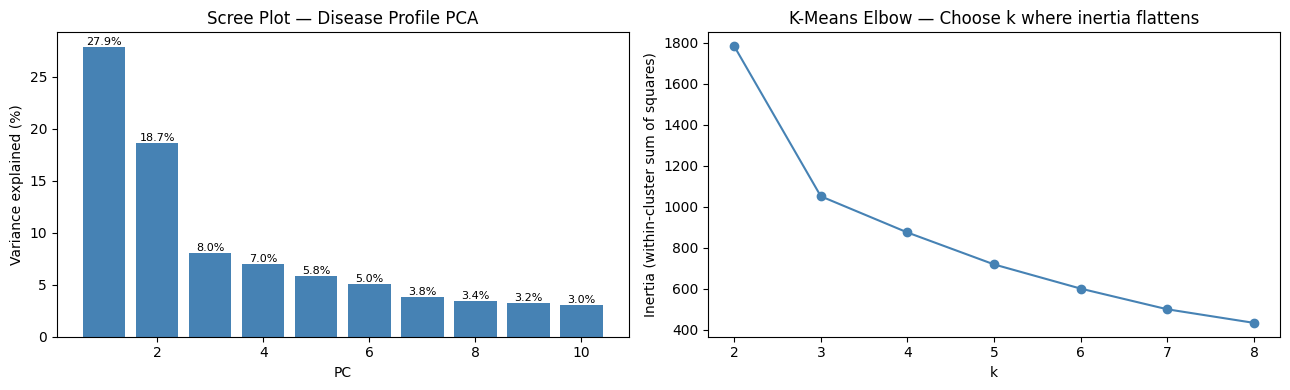

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Operational / aggregate cause names to drop even though they pass the prefix filter
EXCLUDE_CAUSES = {
    "CAUSAS SISTEMA RESPIRATORIO",          # old aggregate, not a leaf
    "CIRUGÍAS DE URGENCIA",                 # procedure type, not a disease
    "Pacientes en espera de hospitalización",
    "Pacientes en espera de hospitalización que esperan menos de 12 horas "
    "para ser trasladados a cama hospitalaria",
}

leaf_urg = df_urgencia_rm[
    ~df_urgencia_rm["GlosaCausa"].str.startswith(("TOTAL", "SECCIÓN", " -"), na=False) &
    ~df_urgencia_rm["GlosaCausa"].isin(EXCLUDE_CAUSES)
].copy()
leaf_urg["id"] = leaf_urg["IdEstablecimiento"].str.strip()

pivot_raw_cl = (
    leaf_urg.groupby(["id", "GlosaCausa"])["Total"].sum()
    .unstack(fill_value=0)
)
pivot_raw_cl = pivot_raw_cl[pivot_raw_cl.sum(axis=1) > 0]
pivot_norm_cl = pivot_raw_cl.div(pivot_raw_cl.sum(axis=1), axis=0)

cause_names_cl = list(pivot_norm_cl.columns)
estab_ids_cl   = pivot_norm_cl.index.tolist()

id_to_pm10_cl = df_estab_rm.set_index("id")["nearest_pm10"].to_dict()
id_to_type_cl = df_estab_rm.set_index("id")["TipoEstablecimientoGlosa"].to_dict()
pm10_arr_cl   = np.array([id_to_pm10_cl.get(i, np.nan) for i in estab_ids_cl])
type_arr_cl   = np.array([id_to_type_cl.get(i, "Unknown") for i in estab_ids_cl])

print(f"Establishments : {len(pivot_norm_cl)}")
print(f"Leaf causes    : {len(cause_names_cl)}")
print(f"PM10 coverage  : {np.isfinite(pm10_arr_cl).sum()} / {len(pm10_arr_cl)} establishments")
print(f"\nCauses included:")
for c in sorted(cause_names_cl):
    print(f"  {c}")

X_cl    = pivot_norm_cl.values
scaler_cl = StandardScaler()
X_cl_sc = scaler_cl.fit_transform(X_cl)

n_comp_cl = min(10, X_cl.shape[0] - 1, X_cl.shape[1])
pca_cl    = PCA(n_components=n_comp_cl)
scores_cl = pca_cl.fit_transform(X_cl_sc)

cum_var_cl = np.cumsum(pca_cl.explained_variance_ratio_) * 100
print(f"\nVariance explained — PC1: {pca_cl.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC1+2: {cum_var_cl[1]:.1f}%  first 5: {cum_var_cl[4]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, n_comp_cl + 1), pca_cl.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree Plot — Disease Profile PCA")
for i, v in enumerate(pca_cl.explained_variance_ratio_ * 100):
    axes[0].text(i + 1, v + 0.2, f"{v:.1f}%", ha="center", fontsize=8)

inertias_cl = [
    KMeans(n_clusters=k, random_state=42, n_init=10).fit(scores_cl[:, :5]).inertia_
    for k in range(2, 9)
]
axes[1].plot(range(2, 9), inertias_cl, "o-", color="steelblue")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Inertia (within-cluster sum of squares)")
axes[1].set_title("K-Means Elbow — Choose k where inertia flattens")
plt.tight_layout()
plt.show()

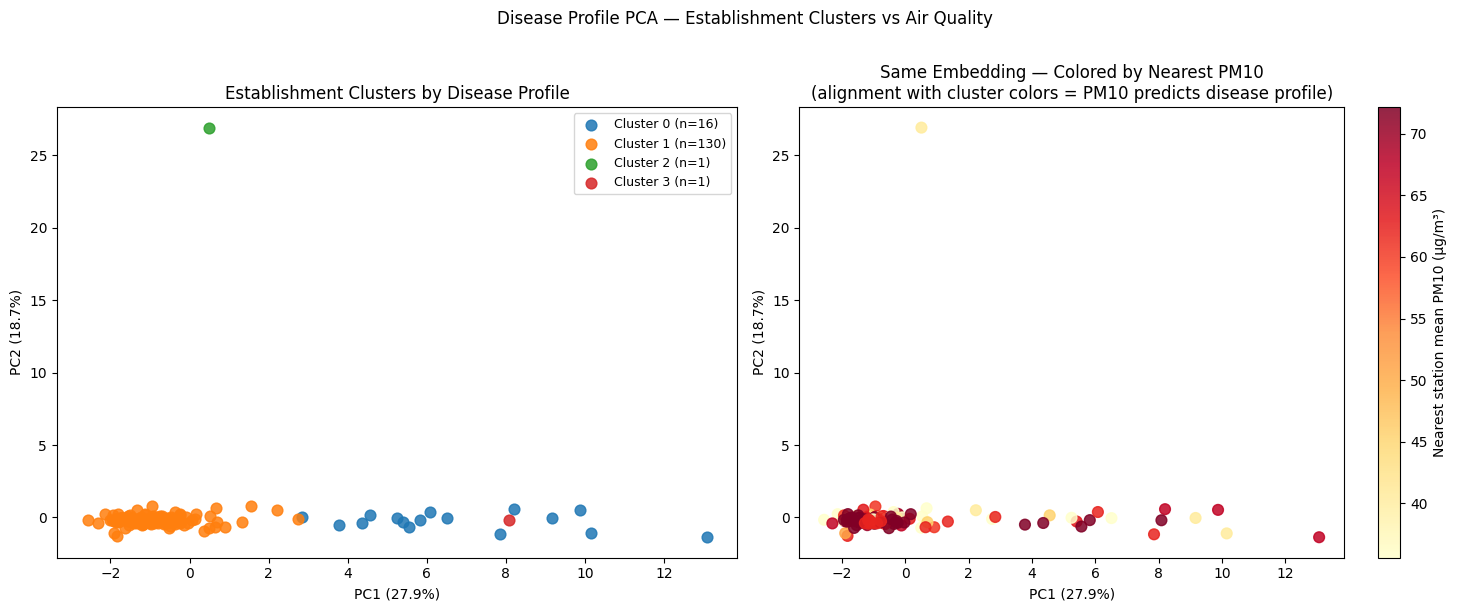

Cluster summary (sorted by mean PM10):


,n,mean_pm10,std_pm10
cluster,,,
3,1,72.15,NaN
0,16,58.54,13.86
1,121,57.80,13.58
2,1,40.58,NaN



Kruskal-Wallis PM10 across clusters: H = 2.99, p = 0.3938


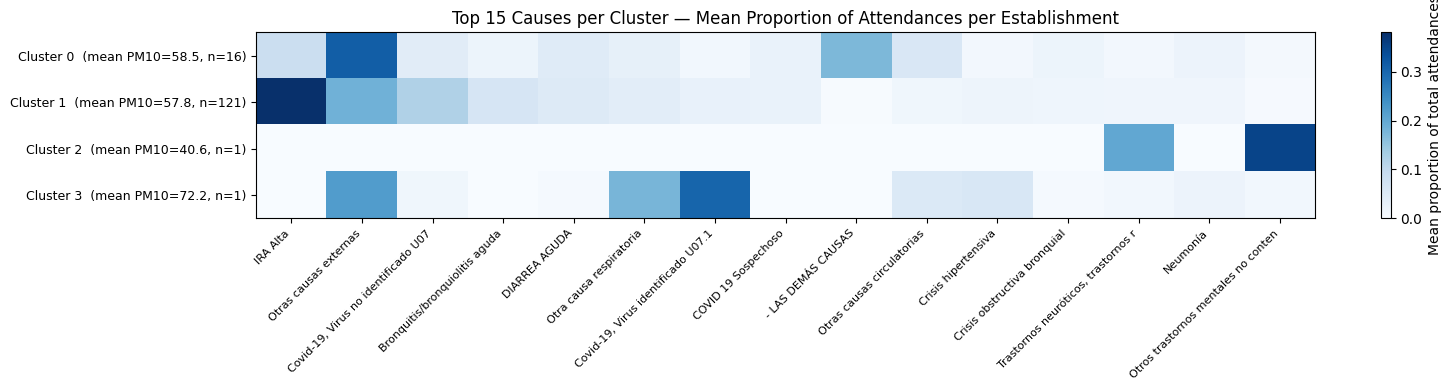

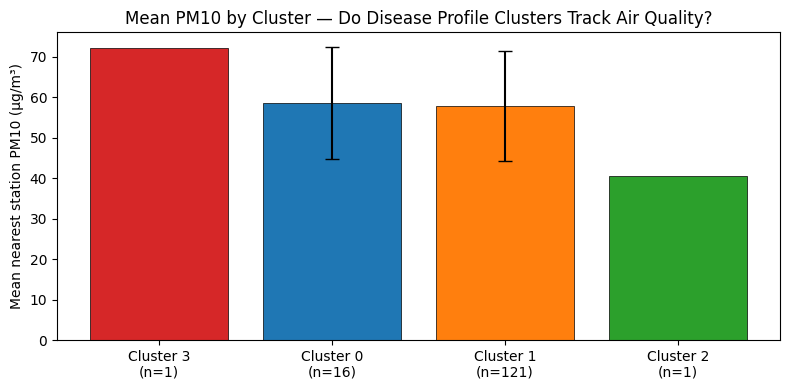

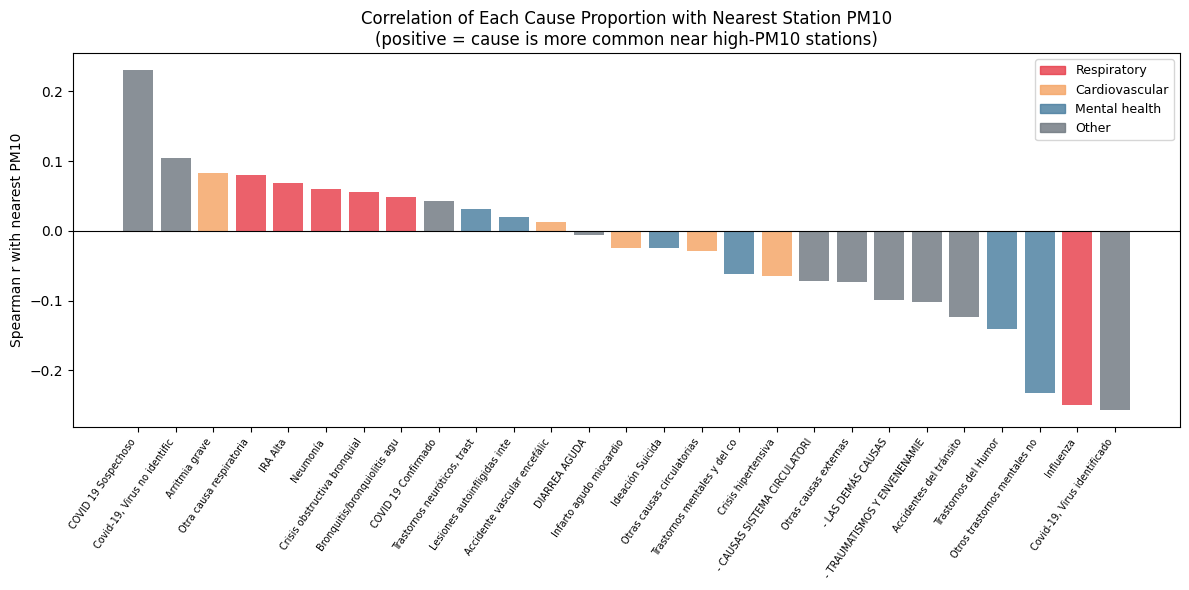


Top positive correlations with PM10 (cause more common near polluted stations):


,cause,r,p,category
0,COVID 19 Sospechoso (U07.2),0.230,0.006,Other
1,"Covid-19, Virus no identificado U07.2",0.104,0.224,Other
2,Arritmia grave,0.082,0.336,Cardiovascular
3,"Otra causa respiratoria (J22, J30-J39, J47, J6...",0.081,0.345,Respiratory
4,IRA Alta (J00-J06),0.068,0.426,Respiratory
5,Neumonía (J12-J18),0.059,0.487,Respiratory
6,Crisis obstructiva bronquial (J40-J46),0.055,0.519,Respiratory
7,Bronquitis/bronquiolitis aguda (J20-J21),0.049,0.565,Respiratory



Top negative correlations with PM10 (cause less common near polluted stations):


,cause,r,p,category
19,Otras causas externas,-0.073,0.392,Other
20,- LAS DEMÁS CAUSAS,-0.099,0.246,Other
21,- TRAUMATISMOS Y ENVENENAMIENTOS,-0.101,0.235,Other
22,Accidentes del tránsito,-0.123,0.150,Other
23,Trastornos del Humor (Afectivos) (F30-F39),-0.141,0.098,Mental health
24,Otros trastornos mentales no contenidos en las...,-0.232,0.006,Mental health
25,Influenza (J09-J11),-0.249,0.003,Respiratory
26,"Covid-19, Virus identificado U07.1",-0.257,0.002,Other


In [18]:
N_CLUSTERS = 4  # adjust based on elbow plot above

km_cl     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cl_labels = km_cl.fit_predict(scores_cl[:, :5])

cmap_cl = plt.colormaps.get_cmap("tab10")

# ── Biplots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cl in range(N_CLUSTERS):
    mask = cl_labels == cl
    axes[0].scatter(scores_cl[mask, 0], scores_cl[mask, 1],
                    label=f"Cluster {cl} (n={mask.sum()})",
                    color=cmap_cl(cl), s=60, alpha=0.85)
axes[0].set_xlabel(f"PC1 ({pca_cl.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_cl.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Establishment Clusters by Disease Profile")
axes[0].legend(fontsize=9)

sc2 = axes[1].scatter(scores_cl[:, 0], scores_cl[:, 1],
                      c=pm10_arr_cl, cmap="YlOrRd", s=60, alpha=0.85)
plt.colorbar(sc2, ax=axes[1], label="Nearest station mean PM10 (µg/m³)")
axes[1].set_xlabel(f"PC1 ({pca_cl.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_cl.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Same Embedding — Colored by Nearest PM10\n(alignment with cluster colors = PM10 predicts disease profile)")

fig.suptitle("Disease Profile PCA — Establishment Clusters vs Air Quality", y=1.01)
plt.tight_layout()
plt.show()

# ── Cluster metadata ────────────────────────────────────────────────────────
cl_df = pd.DataFrame({
    "cluster":      cl_labels,
    "nearest_pm10": pm10_arr_cl,
    "estab_type":   type_arr_cl,
}, index=estab_ids_cl)

cl_summary = (
    cl_df.groupby("cluster")
    .agg(n=("nearest_pm10", "count"),
         mean_pm10=("nearest_pm10", "mean"),
         std_pm10=("nearest_pm10", "std"))
    .round(2)
)
print("Cluster summary (sorted by mean PM10):")
display(cl_summary.sort_values("mean_pm10", ascending=False))

h_stat, p_kw = kruskal(*[
    cl_df[cl_df["cluster"] == cl]["nearest_pm10"].dropna()
    for cl in range(N_CLUSTERS)
])
print(f"\nKruskal-Wallis PM10 across clusters: H = {h_stat:.2f}, p = {p_kw:.4f}")

# ── Cause heatmap per cluster ───────────────────────────────────────────────
pivot_with_cl = pivot_norm_cl.copy()
pivot_with_cl["cluster"] = cl_labels
cl_profiles = pivot_with_cl.groupby("cluster").mean()

# Top 15 causes by mean proportion across all establishments
top15 = pivot_norm_cl.mean().sort_values(ascending=False).head(15).index
cl_top = cl_profiles[top15]

# Short labels: strip ICD code suffixes for readability
short_labels = [c.split("(")[0].strip()[:35] for c in top15]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(cl_top.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(top15))); ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(N_CLUSTERS))
ax.set_yticklabels(
    [f"Cluster {i}  (mean PM10={cl_summary.loc[i,'mean_pm10']:.1f}, n={int(cl_summary.loc[i,'n'])})"
     for i in range(N_CLUSTERS)],
    fontsize=9,
)
plt.colorbar(im, ax=ax, label="Mean proportion of total attendances")
ax.set_title("Top 15 Causes per Cluster — Mean Proportion of Attendances per Establishment")
plt.tight_layout()
plt.show()

# ── PM10 bar per cluster ────────────────────────────────────────────────────
cl_order = cl_summary.sort_values("mean_pm10", ascending=False).index
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(N_CLUSTERS),
       cl_summary.loc[cl_order, "mean_pm10"],
       yerr=cl_summary.loc[cl_order, "std_pm10"],
       color=[cmap_cl(cl) for cl in cl_order],
       capsize=5, edgecolor="k", linewidth=0.5)
ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels([f"Cluster {cl}\n(n={int(cl_summary.loc[cl,'n'])})" for cl in cl_order])
ax.set_ylabel("Mean nearest station PM10 (µg/m³)")
ax.set_title("Mean PM10 by Cluster — Do Disease Profile Clusters Track Air Quality?")
plt.tight_layout()
plt.show()

# ── Spearman: PM10 vs each cause proportion (non-respiratory highlighted) ──
RESP_KEYWORDS = ("IRA", "Bronquitis", "Influenza", "Neumonía", "Crisis obstructiva", "respiratoria")
CARDIO_KEYWORDS = ("vascular", "Arritmia", "hipertensiva", "miocardio", "circulatoria")
MENTAL_KEYWORDS = ("Trastorno", "Suicida", "autoinfligida", "psicoactiva", "mental")

cause_corrs = []
for cause in cause_names_cl:
    x = pm10_arr_cl
    y = pivot_norm_cl[cause].values
    valid = np.isfinite(x)
    r, p = spearmanr(x[valid], y[valid])
    category = ("Respiratory" if any(kw in cause for kw in RESP_KEYWORDS)
                 else "Cardiovascular" if any(kw in cause for kw in CARDIO_KEYWORDS)
                 else "Mental health" if any(kw in cause for kw in MENTAL_KEYWORDS)
                 else "Other")
    cause_corrs.append({"cause": cause, "r": r, "p": p, "category": category})

corr_df = (pd.DataFrame(cause_corrs)
           .sort_values("r", ascending=False)
           .reset_index(drop=True))

cat_colors = {"Respiratory": "#e63946", "Cardiovascular": "#f4a261",
              "Mental health": "#457b9d", "Other": "#6c757d"}

fig, ax = plt.subplots(figsize=(12, 6))
for _, row in corr_df.iterrows():
    ax.bar(row.name, row["r"], color=cat_colors[row["category"]], alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(corr_df)))
ax.set_xticklabels([c.split("(")[0].strip()[:28] for c in corr_df["cause"]],
                   rotation=55, ha="right", fontsize=7)
ax.set_ylabel("Spearman r with nearest PM10")
ax.set_title("Correlation of Each Cause Proportion with Nearest Station PM10\n"
             "(positive = cause is more common near high-PM10 stations)")
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.8) for c in cat_colors.values()]
ax.legend(handles, cat_colors.keys(), fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop positive correlations with PM10 (cause more common near polluted stations):")
display(corr_df[corr_df["r"] > 0][["cause", "r", "p", "category"]].head(8).round(3))
print("\nTop negative correlations with PM10 (cause less common near polluted stations):")
display(corr_df[corr_df["r"] < 0][["cause", "r", "p", "category"]].tail(8).round(3))

## 13. Conclusions — Spatial and Unsupervised Analyses

### Section 11: Does Nearby PM10 Predict Respiratory Emergency Rate?

**Result: No significant individual-level relationship (Spearman r = 0.073, p = 0.395, n = 139).**

After controlling for establishment size by converting raw attendance counts to a *respiratory rate* (respiratory attendances / total urgencia attendances), the cross-establishment correlation between nearest-station PM10 and disease burden is near zero and statistically non-significant. The scatter is wide and no trend line can be separated from noise.

However, stratifying by establishment type reveals a clear functional hierarchy:

| Establishment type | Mean respiratory rate | Mean nearest PM10 (µg/m³) |
|---|---|---|
| CESFAM (primary care) | **38.0%** | **62.0** |
| SAPU (urban urgency) | 27.8% | 59.4 |
| SAPUAM (after-hours urgency) | 22.3% | 58.9 |
| SUR (rural urgency) | 23.4% | 47.8 |
| Hospital | **12.9%** | 54.7 |

The pattern is directionally consistent — CESFAMs sit in the highest-PM10 areas and also have the highest respiratory rates — but this association is structurally confounded: CESFAMs are neighbourhood clinics whose core function is treating acute respiratory illness (IRA, bronchitis, asthma), regardless of local air quality. Hospitals see a much broader emergency mix (trauma, cardiac events, surgical referrals), which mechanically lowers their respiratory fraction. Isolating a PM10 effect requires controlling for establishment function and socioeconomic catchment area, neither of which is available in this dataset.

**Key limitation:** With only 12 air monitoring stations covering all of RM, many establishments share the same nearest-station PM10 value. The spatial resolution is too coarse to detect within-commune pollution gradients that could drive establishment-level differences.

---

### Section 12: Unsupervised Clustering — Disease Profile and Air Quality

**Result: Disease profile clusters do not track PM10 exposure (Kruskal-Wallis H = 2.99, p = 0.394).**

**PCA of disease profiles:**  
The 27-cause disease profile matrix is dominated by a single large cluster: K-means (k = 4) assigns 121 of 148 establishments (82%) to one group, with one secondary cluster of 16 and two singletons. The two singletons anchor the extremes of the PM10 range (72.1 and 40.6 µg/m³) but are not interpretable as clusters. The PCA scree plot shows moderate variance concentration — PC1 accounts for 27.9%, the first two together 46.5%, the first five 67.4% — reflecting that disease mix varies along several independent axes rather than one dominant "pollution axis."

The Kruskal-Wallis test across four clusters (H = 2.99, p = 0.394) confirms that **clusters defined purely by disease profile do not systematically differ in their air quality exposure**. The null hypothesis cannot be rejected: knowing an establishment's disease mix does not predict whether it sits near a high- or low-PM10 station.

**Individual cause correlations with PM10:**

Only four of 27 causes reach statistical significance (p < 0.01), and their interpretation points to socioeconomic confounding rather than direct air quality effects:

| Cause | Spearman r | p | Likely explanation |
|---|---|---|---|
| COVID sospechoso (suspected) | **+0.230** | 0.006 | High-PM10 areas (lower-income) have less PCR testing capacity → more unconfirmed cases |
| COVID confirmado (confirmed) | **−0.257** | 0.002 | Mirror of the above: fewer lab confirmations per case |
| Influenza | **−0.249** | 0.003 | High-PM10 areas have more IRA/bronchitis that dilutes the influenza proportion; or lower vaccination rates shift presentation to non-specific diagnoses |
| Otros trastornos mentales | **−0.232** | 0.006 | High-PM10 (lower-income) areas have lower mental health service capacity; mental health emergencies may not reach the urgencia system |

**Respiratory and cardiovascular causes show the expected direction but do not reach significance:**

- All respiratory causes (IRA Alta, bronquitis, crisis obstructiva, neumonía, other respiratory) trend positively with PM10 (r = 0.05–0.08), consistent with the established epidemiology. The effect exists but the spatial resolution (12 stations, 148 establishments, many sharing the same PM10 assignment) is insufficient to detect it at p < 0.05.
- Cardiovascular causes (arritmia, infarto, crisis hipertensiva) show small positive correlations (r ≈ 0.06–0.08), also non-significant. PM2.5 is a known independent risk factor for cardiovascular disease in the literature, but detecting this effect spatially would require finer pollution exposure estimates (e.g., land-use regression modelling) rather than nearest-station assignment.

---

### Synthesis — Spatial vs Temporal Signal

The spatial analyses (Sections 10–12) consistently find **weaker and non-significant** associations compared to the temporal analyses (Sections 1–9). The key reason is resolution: temporally, air pollution and respiratory emergencies co-vary week by week with the winter inversion cycle — a strong, recurring, city-wide signal. Spatially, the signal is much finer: it would require distinguishing a CESFAM at 60 µg/m³ from one at 55 µg/m³, a difference smaller than the station-to-station variability introduced by having only 12 monitoring points.

Three findings hold across both analytical angles:

1. **The pollution–health direction is consistent.** More PM10 → more respiratory burden, at every scale examined. The effect is just too small relative to establishment-function and socioeconomic confounders to reach significance in the spatial dimension.

2. **Establishment type and socioeconomic area are stronger determinants of disease mix than PM10 at this granularity.** CESFAMs have the highest respiratory rates regardless of their specific PM10 value; the COVID diagnostic split (suspected vs confirmed) tracks income/testing access more than any pollutant.

3. **The most actionable finding from the spatial analysis is structural:** the RM monitoring network is sparse for health-burden linkage analysis. Expanding it (particularly in the high-respiratory-burden western RM communes of Pudahuel, Cerro Navia, Lo Prado) would allow credible establishment-level exposure assignment and could unlock the spatial pollution–health signal that the temporal analysis already suggests is real.

---

### Recommended next steps to unlock the spatial signal

| Step | Expected improvement |
|---|---|
| Use land-use regression or kriging to estimate PM10 at each establishment's exact coordinates | Removes the "many establishments share one station" problem |
| Add commune-level SES controls (median income, education, overcrowding from Census) | Separates PM10 effect from socioeconomic gradient |
| Repeat analysis at the daily level with 7- and 14-day lagged PM10 | Captures acute exposure response; eliminates seasonal confounding |
| Filter to IRA Alta (J00–J06) and crisis obstructiva (J40–J46) only | These are the most PM10-proximate diagnoses; reduces heterogeneous "other respiratory" noise |
